<a href="https://colab.research.google.com/github/EstivenA/Practica4_Vision_computador_IA/blob/main/Reto3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Tomado de https://keras.io/examples/vision/autoencoder/
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import re
import random
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from keras import backend
tamano = 512
xy = tamano

def preprocess (array):
  """
  Normalizes the supplied array and reshapes it into the appropriate format.
  """
  array = array.astype("float32") / 255.0
  array = np.reshape(array, (len(array), tamano, tamano, 1))
  return array

def display(array1, array2):
  """
  Displays ten random images from each one of the supplied arrays.
  """
  n = 5
  indices = np.random.randint(len(array1), size=n)
  images1 = array1[indices, :]
  images2 = array2[indices, :]
  plt.figure(figsize=(20, 4))
  for i, (image1, image2) in enumerate(zip(images1, images2)):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(image1.reshape(tamano, tamano))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(image2.reshape(tamano, tamano))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
  plt.show()

**Montar carpeta Drive**

In [ ]:
from google.colab import drive
drive.mount('/drive', force_remount=True)
drive_path = '/drive/MyDrive/Main folder/'
gt_path = 'GTruth'
noisy_path = 'Noisy'
test_path = 'GTruth_val'
val_path = 'Noisy_Val'
write_path = 'Noisy_Filt_3_69'

Mounted at /drive


**Cargar imágenes Ground Truth**

In [ ]:
# Cargar imagenes desde carpeta en Drive
dirname = os.path.join(os.getcwd(), '/drive/MyDrive/Main folder/' + gt_path)

# Obtenemos todos los archivos y seleccionamos 500
all_files = sorted([f for f in os.listdir(dirname) if re.search("\.(jpg|jpeg|png|bmp|tiff)$", f)])
random.seed(42)
files = random.sample(all_files, 500) # Esta es la lista maestra de 500 nombres

images = []
cant = 0
for filename in files:
    filepath = os.path.join(dirname, filename)
    image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (xy, xy))
    images.append(image)
    cant = cant + 1
    if cant % 100 == 0: print(f"Leyendo GTruth... {cant}")

print("Total imagenes GTruth: ", len(images))

<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_5080/2103311765.py:5: SyntaxWarning: invalid escape sequence '\.'
  all_files = sorted([f for f in os.listdir(dirname) if re.search("\.(jpg|jpeg|png|bmp|tiff)$", f)])


Leyendo GTruth... 100
Leyendo GTruth... 200
Leyendo GTruth... 300
Leyendo GTruth... 400
Leyendo GTruth... 500
Total imagenes GTruth:  500


**Cargar imágenes con ruido**

In [ ]:
# Cargar imagenes desde carpeta en Drive
dirname2 = os.path.join(os.getcwd(), '/drive/MyDrive/Main folder/' + noisy_path)
images_noisy = []
cant2 = 0
for filename in files:
    # Ajuste de extensión si es necesario (.png -> .tiff)
    filename_noisy = filename.replace('.png', '.tiff')
    filepath2 = os.path.join(dirname2, filename_noisy)
    image_noisy = cv2.imread(filepath2, cv2.IMREAD_GRAYSCALE)
    image_noisy = cv2.resize(image_noisy, (xy, xy))
    images_noisy.append(image_noisy)
    cant2 = cant2 + 1
    if cant2 % 100 == 0: print(f"Leyendo Noisy... {cant2}")

print("Total imagenes Noisy: ", len(images_noisy))

Leyendo Noisy... 100
Leyendo Noisy... 200
Leyendo Noisy... 300
Leyendo Noisy... 400
Leyendo Noisy... 500
Total imagenes Noisy:  500


In [ ]:
print('Tamaño GTruth: ', len(images))
print('Tamaño Noisy: ', len(images_noisy))

Tamaño GTruth:  500
Tamaño Noisy:  500


**Organización de datos train y test**

### Sequential

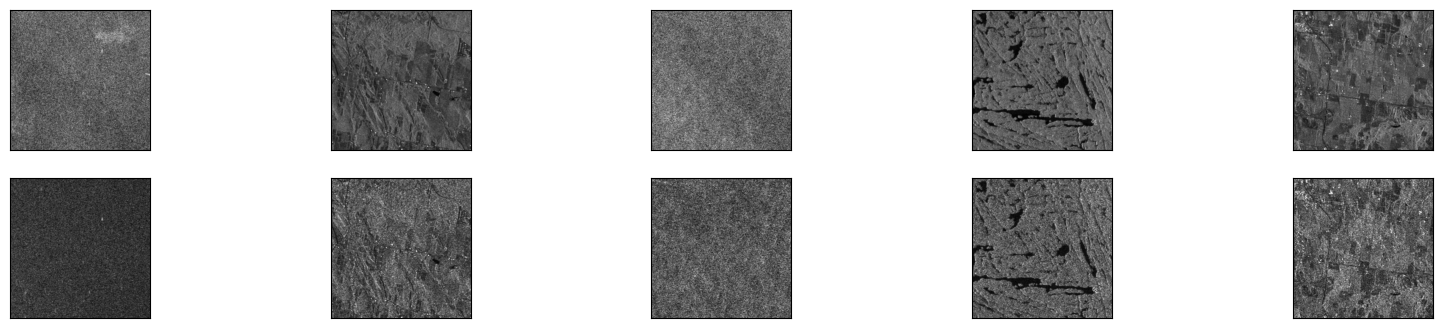

In [ ]:
# Since we only need images from the dataset to encode and decode, we won't use the labels.
# Ground Truth
X = np.array(images, dtype = np.uint8)
X_train, X_test = train_test_split(X, test_size=0.15, random_state=123)
# Noisy
X_noisy = np.array(images_noisy, dtype = np.uint8)
X_noisy_train, X_noisy_test = train_test_split(X_noisy, test_size=0.15, random_state=123)

# Normalize and reshape the data
# Ground Truth
train_data = preprocess(X_train)
test_data = preprocess(X_test)
# Noisy
noisy_train_data = preprocess(X_noisy_train)
noisy_test_data = preprocess(X_noisy_test)
# Display
display(train_data, noisy_train_data)

### Non sequential - U-Net

In [ ]:
# Preparación de datos
X = np.array(images, dtype = np.uint8)
X_train, X_test = train_test_split(X, test_size=0.15, random_state=123)
X_noisy = np.array(images_noisy, dtype = np.uint8)
X_noisy_train, X_noisy_test = train_test_split(X_noisy, test_size=0.15, random_state=123)

train_data = preprocess(X_train)
test_data = preprocess(X_test)
noisy_train_data = preprocess(X_noisy_train)
noisy_test_data = preprocess(X_noisy_test)

### Importaciones

In [ ]:
#Imports
from tensorflow.python.ops import array_ops
from tensorflow.python.framework import constant_op
from tensorflow.python.ops import nn

### Sequential

In [ ]:
# Define the model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, LeakyReLU
from tensorflow.keras.optimizers import Adam

input_img = Input(shape=(tamano, tamano, 1))

x = Conv2D(128, (3, 3), padding="same")(input_img)
x = LeakyReLU(alpha=0.1)(x) # Mejor que ReLU para no perder información negativa
x = MaxPooling2D((2, 2), padding="same")(x)

x = Conv2D(256, (3, 3), padding="same")(x)
x = LeakyReLU(alpha=0.1)(x)
x = MaxPooling2D((2, 2), padding="same")(x)

# Bottleneck
x = Conv2D(512, (3, 3), padding="same")(x)
x = LeakyReLU(alpha=0.1)(x)
# Decoder
x = Conv2DTranspose(256, (3, 3), strides=2, padding="same")(x)
x = LeakyReLU(alpha=0.1)(x)

x = Conv2DTranspose(128, (3, 3), strides=2, padding="same")(x)
x = LeakyReLU(alpha=0.1)(x)

output = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder = Model(input_img, output)

opt = Adam(learning_rate=0.0001)

autoencoder.compile(optimizer=opt, loss="mse")
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 512, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 512, 512, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 256, 256, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 256, 256, 128)  │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 512, 512, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 512, 512, 1)    │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,073 (2.82 MB)

 Trainable params: 739,073 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

### Non sequential

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate

def build_unet():
    inputs = Input(shape=(tamano, tamano, 1))
    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D((2, 2))(c1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    p2 = MaxPooling2D((2, 2))(c2)

    # Bridge
    b = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)

    # Decoder con conexiones residuales (Merge)
    u1 = UpSampling2D((2, 2))(b)
    m1 = concatenate([u1, c2]) # Conexión no secuencial
    c3 = Conv2D(128, (3, 3), activation='relu', padding='same')(m1)

    u2 = UpSampling2D((2, 2))(c3)
    m2 = concatenate([u2, c1]) # Conexión no secuencial
    c4 = Conv2D(64, (3, 3), activation='relu', padding='same')(m2)

    output = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(c4)
    return Model(inputs, output)

autoencoder = build_unet()
autoencoder.compile(optimizer="adam", loss="mse", metrics=['mae'])
autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 512, 512,  │        640 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 256, 256,  │          0 │ conv2d_15[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 256, 256,  │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 128, 128,  │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │    295,168 │ max_pooling2d_9[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 256, 256,  │          0 │ conv2d_17[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 256, 256,  │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 512, 512,  │          0 │ conv2d_18[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512, 512,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 512, 512,  │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 512, 512,  │        577 │ conv2d_19[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 923,393 (3.52 MB)

 Trainable params: 923,393 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

**TRAIN FIRST WITH GT2**

In [ ]:
autoencoder.fit(x=noisy_train_data, y=train_data, epochs=50, batch_size=4, shuffle=True, validation_data=(noisy_test_data, test_data))

Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 94s 592ms/step - loss: 0.0094 - mae: 0.0634 - val_loss: 0.0028 - val_mae: 0.0388
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 353ms/step - loss: 0.0032 - mae: 0.0434 - val_loss: 0.0027 - val_mae: 0.0390
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 352ms/step - loss: 0.0027 - mae: 0.0390 - val_loss: 0.0026 - val_mae: 0.0380
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 352ms/step - loss: 0.0026 - mae: 0.0388 - val_loss: 0.0039 - val_mae: 0.0500
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 351ms/step - loss: 0.0030 - mae: 0.0418 - val_loss: 0.0024 - val_mae: 0.0365
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 349ms/step - loss: 0.0025 - mae: 0.0380 - val_loss: 0.0025 - val_mae: 0.0382
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 349ms/step - loss: 0.0025 - mae: 0.0379 - val_loss: 0.0023 - val_mae: 0.0360
Epoch 8/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 349ms/step - loss: 0.0027 - mae: 0.0397 - val_loss: 0.0023 - val_mae: 0.0361
Epoch 9/50
107/107 ━━━━━━━━━━━━━

75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


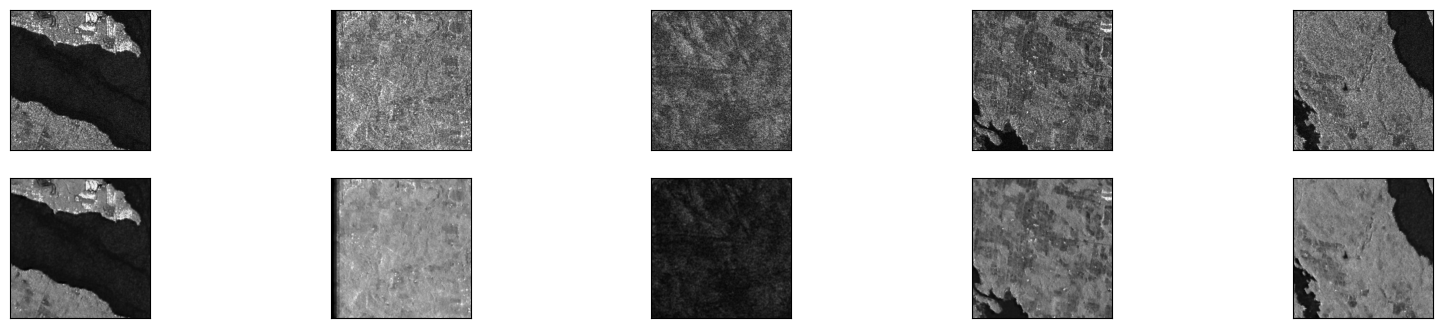

In [ ]:
predictions = autoencoder.predict(noisy_test_data, batch_size=1)
display(noisy_test_data, predictions)

**Guardado y cargado del modelo en Drive**

In [ ]:
autoencoder.save('/drive/MyDrive/Main folder/mymodel.h5')
from tensorflow import keras
autoencoder_loaded = keras.models.load_model('/drive/MyDrive/Main folder/mymodel.h5')

**Validación con nuevas imágenes**

In [ ]:
TEST_PATH = '/drive/MyDrive/Main folder/' + val_path
test_ids= []
try:
    test_ids = next(os.walk(TEST_PATH))[2]
except StopIteration:
    pass
print(test_ids)


for i in test_ids:
  img = i
  print(img)
  val1 = cv2.imread('/drive/MyDrive/Main folder/' + val_path + '/' + img, cv2.IMREAD_GRAYSCALE)
  if val1 is None:
      print(f"Warning: Could not read image {img}. Skipping.")
      continue
  val1 = cv2.resize(val1, (xy, xy))
  sfs = []
  sfs.append(val1)
  valid = np.array(sfs, dtype = np.uint8)
  valida = preprocess(valid)
  prediction = autoencoder.predict(valida)
  plt.imshow(prediction.reshape(xy, xy, 1))
  img = img.replace("tiff", "png")
  cv2.imwrite('/drive/MyDrive/Main folder/' + write_path + '/' + img, prediction.reshape(xy, xy, 1)*255)


[]


### PSNR, SSIM y ENL

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def calculate_enl(image):
    return np.mean(image)**2 / np.var(image)

idx = 0
img_original = test_data[idx].reshape(tamano, tamano)
img_reconstruida = predictions[idx].reshape(tamano, tamano)

v_psnr = psnr(img_original, img_reconstruida, data_range=1.0)
v_ssim = ssim(img_original, img_reconstruida, data_range=1.0)
v_enl = calculate_enl(img_reconstruida)

print("--- RESULTADOS MODELO ---")
print(f"PSNR (Calidad de píxel): {v_psnr:.2f} dB")
print(f"SSIM (Similitud de estructura): {v_ssim:.4f}")
print(f"ENL (Suavizado del ruido speckle): {v_enl:.4f}")

--- RESULTADOS MODELO ---
PSNR (Calidad de píxel): 26.40 dB
SSIM (Similitud de estructura): 0.6106
ENL (Suavizado del ruido speckle): 101.7571


### Conclusiones

- Al empezar con el código brindado en clase obtuvimos un valor de PSNR de 26.07 dB que nos mestra una reconstrucción deficiente de la información estructural de las imágenes SAR, un valor de SSIM de 0.5814, lo cual es bastante bajo, por esto la imagen se ve borrosa y casi no se alcanzan a rescatar muchos detalles de la imagen original y un valor de enl de 72.6745. Asi que decidimos investigar que tipo de función de pérdida se acomodaba mejor a nuestro ejercicio y descubrimos que la funcion "binary_crossentropy" está diseñada para clasificar entre blanco y negro pero no se preocupa mucho por los tonos grises intermedios, a diferencia de la función "mse" que calcula el promedio de la diferencia al cuadrado entre el píxel real y el predicho. Esto hace que la red trate de que el valor de gris de cada píxel sea numéricamente lo más cercano posible al original, lo que mejora bastante el PSNR.
- También aumentamos el numero de filtros para que el modelo tenga mas capacidad de memoria y mas capacidad de distinguir bordes y figuras, asi evita confundir ruido con información importante.
- Agregamos una capa intermedia (cuello de botella) de 256 filtros para permitir que la red guarde información más compleja antes de intentar reconstruir la imagen ya que si esta capa es muy pequeña, la imagen resultante saldrá muy borrosa.
- Disminuimos el batch_size para que se detenga mas seguido a corregir errores y para que aprenda mas detalles finos del ruido, aunque el tiempo de entrenamiento aumentó significativamente, creemos que vale la pena. Al final los resultados no fueron los mejores en gterminos de gran diferencia entre el codigo inicial y el codigo final pero si mejoró un poquito:

- PSNR 26.07 -> 26.18 dB
- SSIM 0.5814 -> 0.5977
- ENL 72.6745 -> 81.5857
- Cuando mejoramos el sistema usando un modelo no secuencial (U-Net) se notó una gran diferencia ya que este modelo tiene atajos que permiten que los detalles finos de la imagen original pasen directamente al resultado final. Gracias a esto, logramos resultados mucho mejores como estos:

- PSNR 26.18 -> 26.40 dB
- SSIM 0.5977 -> 0.6106
- ENL 81.5857 -> 101.7571